In [1]:
!pip install pandas scikit-learn matplotlib stopwordsiso

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached stopwordsiso-0.7.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached numpy-2.5.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.18.1-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp313-cp313-win_amd64.whl.metadata (126 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Us

ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: 'C:\\Users\\Punam kumari\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\narwhals-2.25.0.dist-info\\INSTALLER'
Consider using the `--user` option or check the permissions.



In [2]:
import pandas as pd
import re
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import stopwordsiso as stopwords

ModuleNotFoundError: No module named 'pandas'

In [3]:
%pip install pandas numpy scikit-learn stopwordsiso



Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import re
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import stopwordsiso as stopwords


In [5]:
df = pd.read_csv("bbc_hindi_articles_with_categories_cleaned(3).csv")

print("Dataset shape:", df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'bbc_hindi_articles_with_categories_cleaned(3).csv'

In [6]:
import pandas as pd

df = pd.read_csv("bbc_hindi_articles_with_categories_cleaned(3).csv")

print(df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'bbc_hindi_articles_with_categories_cleaned(3).csv'

In [7]:
import pandas as pd

df = pd.read_csv("bbc_hindi_articles_with_categories-cleaned.csv")

print("Dataset shape:", df.shape)
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'bbc_hindi_articles_with_categories-cleaned.csv'

In [8]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\Punam kumari
['.copilot', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.TurboVPN', '.vscode', '.vscode-shared', 'AppData', 'Application Data', 'bbc_hindi_articles_with_categories_cleaned.csv', 'c programming', 'c tutorial', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'html_practice', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'loop.py', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'Postman', 'practice 3.py', 'practice 4.py', 'PrintHood', 'python.py', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'Templates', 'Untitled.ipynb', 'untitled.py', 'Untitled1.ipynb', 'Untitled2.ipynb', 'Videos']


In [9]:
import pandas as pd

df = pd.read_csv("bbc_hindi_articles_with_categories_cleaned.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (4796, 3)
                                            Headline  \
0  बांग्लादेश जमात-ए-इस्लामी और मोदी-बाइडन की बात...   
1        भारत में महिलाएं क्यों छिपाती हैं मेनोपॉज़?   
2  वीडियो, 'वडोदरा शहर में करोड़ों रुपए के बंगले ...   
3  अवनि लेखरा: टोक्यो के बाद पेरिस में भी गोल्ड प...   
4  पैरालंपिक में भाग्यश्री जाधव: मेहनत और लगन से ...   

                                             Content Category  
0  प्रधानमंत्री नरेंद्र मोदी और अमेरिका राष्ट्रपत...     भारत  
1  “मेरे पति चाहते थे कि मैं हमेशा तैयार और सज सं...     भारत  
2  गुजरात में लगातार हो रही भारी बारिश के कारण कई...     भारत  
3  अवनि लेखरा ने पेरिस पैरालंपिक में महिलाओं की 1...     भारत  
4  पेरिस पैरालंपिक खेलों की शुरुआत 28 अगस्त से हो...     भारत  


In [10]:
print(df.columns.tolist())

['Headline', 'Content', 'Category']


In [11]:
df["text"] = (
    df["Headline"].fillna("") + " " +
    df["Content"].fillna("")
)

print(df["text"].head())

0    बांग्लादेश जमात-ए-इस्लामी और मोदी-बाइडन की बात...
1    भारत में महिलाएं क्यों छिपाती हैं मेनोपॉज़? “म...
2    वीडियो, 'वडोदरा शहर में करोड़ों रुपए के बंगले ...
3    अवनि लेखरा: टोक्यो के बाद पेरिस में भी गोल्ड प...
4    पैरालंपिक में भाग्यश्री जाधव: मेहनत और लगन से ...
Name: text, dtype: str


In [12]:
import re
import stopwordsiso as stopwords

hindi_stopwords = stopwords.stopwords("hi")

def preprocess_hindi(text):
    text = str(text).lower()

    # Keep Hindi characters and spaces
    text = re.sub(r"[^\u0900-\u097F\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [
        word for word in words
        if word not in hindi_stopwords
        and len(word) > 2
    ]

    return " ".join(words)

df["clean_text"] = df["text"].apply(preprocess_hindi)

print(df["clean_text"].head())

0    बांग्लादेश जमात इस्लामी मोदी बाइडन बातचीत दोनो...
1    भारत महिलाएं क्यों छिपाती मेनोपॉज़ मेरे पति चा...
2    वीडियो वडोदरा शहर करोड़ों रुपए बंगले पीने पानी...
3    अवनि लेखरा टोक्यो पेरिस गोल्ड साधा निशाना अवनि...
4    पैरालंपिक भाग्यश्री जाधव मेहनत लगन भाग्य बदलने...
Name: clean_text, dtype: str


In [13]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=10000
)

X = vectorizer.fit_transform(df["clean_text"])

print("Document-Term Matrix:", X.shape)

Document-Term Matrix: (4796, 2962)


In [14]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda_model.fit(X)

print("LDA model trained successfully!")

LDA model trained successfully!


In [15]:
feature_names = vectorizer.get_feature_names_out()

topic_words = {}

for topic_idx, topic in enumerate(lda_model.components_):

    words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    topic_words[topic_idx + 1] = words

    print(f"\nविषय {topic_idx + 1}")
    print(" | ".join(words))


विषय 1
रत | अम | ओल | कर | उन | मह | सम | मन | टर | डल

विषय 2
टर | तर | रत | कर | सर | पन | बढ | पर | अध | वर

विषय 3
रत | बल | बन | कर | वर | ओवर | दब | उन | इनल | अफ

विषय 4
सरक | रत | कर | मल | रक | अध | शन | उन | सम | आर

विषय 5
इल | इसर | हम | हमल | टर | ईर | अम | कर | सम | बन

विषय 6
रत | कर | पर | मह | उन | पत | हम | सम | बच | बत

विषय 7
कर | दव | सद | सरक | यक | रत | जन | रह | उम | रपत

विषय 8
कर | रह | बन | कप | टर | उन | कह | हर | दर | लग


In [16]:
topic_names = {
    1: "राजनीति",
    2: "अंतरराष्ट्रीय मामले",
    3: "खेल",
    4: "मनोरंजन",
    5: "व्यापार और अर्थव्यवस्था",
    6: "स्वास्थ्य",
    7: "विज्ञान और तकनीक",
    8: "समाज"
}

print("Topic names assigned successfully!")

Topic names assigned successfully!


In [17]:
topic_distribution = lda_model.transform(X)

df["topic"] = topic_distribution.argmax(axis=1) + 1

df["topic_name"] = df["topic"].map(topic_names)

print(df[["Headline", "Category", "topic", "topic_name"]].head(20))

                                             Headline Category  topic  \
0   बांग्लादेश जमात-ए-इस्लामी और मोदी-बाइडन की बात...     भारत      4   
1         भारत में महिलाएं क्यों छिपाती हैं मेनोपॉज़?     भारत      6   
2   वीडियो, 'वडोदरा शहर में करोड़ों रुपए के बंगले ...     भारत      6   
3   अवनि लेखरा: टोक्यो के बाद पेरिस में भी गोल्ड प...     भारत      6   
4   पैरालंपिक में भाग्यश्री जाधव: मेहनत और लगन से ...     भारत      6   
5   चंपाई सोरेन झारखंड में क्या बीजेपी को सत्ता तक...     भारत      7   
6   पुतिन को मंगोलिया में किया जाए गिरफ्तार, अंतरर...     भारत      6   
7   जय शाह: 35 साल की उम्र में क्रिकेट की दुनिया क...     भारत      4   
8   वेस्ट बैंक में इसराइल की कार्रवाई दूसरे दिन भी...     भारत      4   
9   एक दलित अधिकारी रेलवे में सबसे ऊंचे पद पर होंग...     भारत      4   
10  वीडियो, मनु भाकर ने सुनाई पिस्टल खराब होने के ...     भारत      1   
11  क्या हैं भविष्य की पांच नौकरियां और उनके लिए ज...     भारत      2   
12  बांग्लादेश में बाढ़ पर भारत को लेकर ग़ुस्सा, व.

In [18]:
topic_counts = (
    df["topic_name"]
    .value_counts()
)

print(topic_counts)

topic_name
अंतरराष्ट्रीय मामले        785
खेल                        732
समाज                       692
मनोरंजन                    639
व्यापार और अर्थव्यवस्था    577
स्वास्थ्य                  516
विज्ञान और तकनीक           463
राजनीति                    392
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1006217347.py:44: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1006217347.py:44: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1006217347.py:44: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1006217347.py:44: UserWarning: Glyph 2359 (\N{DEVANAGARI LETTER SSA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1006217347.py:44: UserWarning: Glyph 2335 (\N{DEVANAGARI LETTER TTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\L

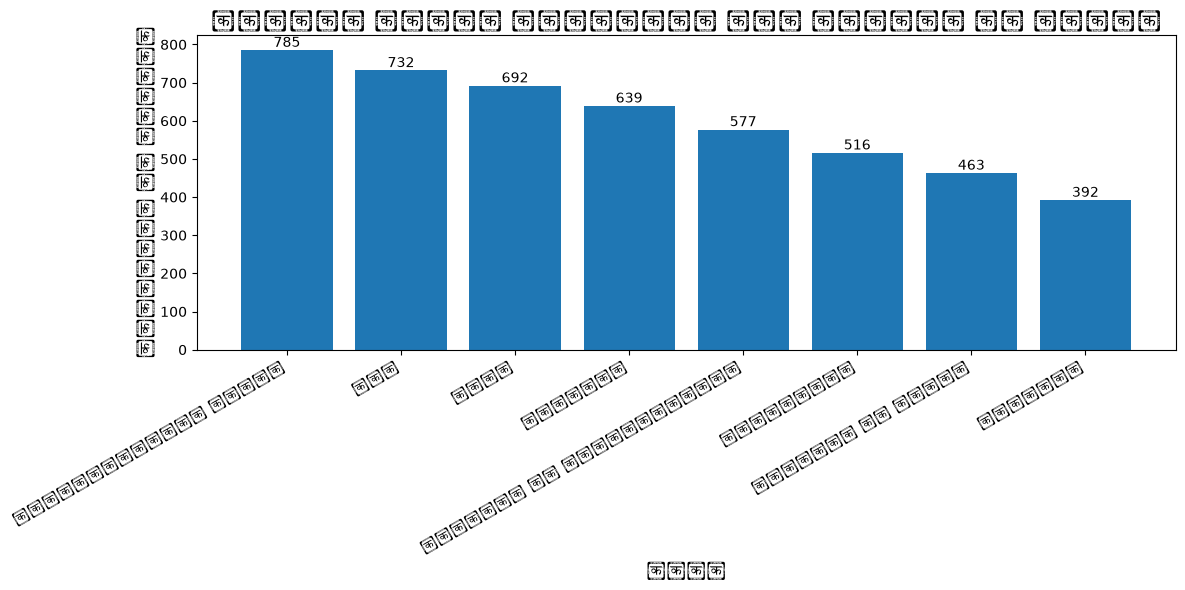

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    topic_counts.index,
    topic_counts.values
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का वितरण",
    fontsize=16
)

plt.xlabel(
    "विषय",
    fontsize=13
)

plt.ylabel(
    "समाचारों की संख्या",
    fontsize=13
)

plt.xticks(
    rotation=30,
    ha="right",
    fontsize=11
)

# Numbers above bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2

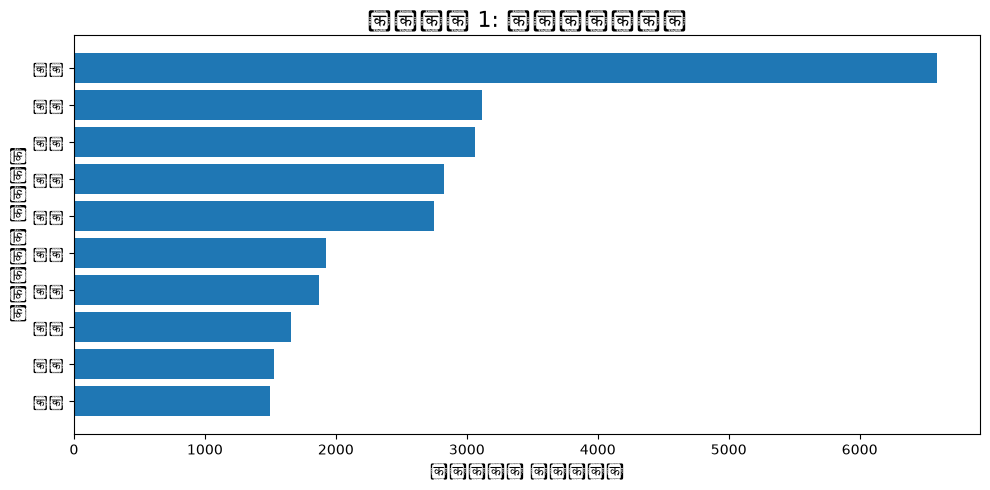

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2338 (\N{DEVANAGARI LETTER DDHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2338 (\N{DEVANAGARI LETTER DDHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

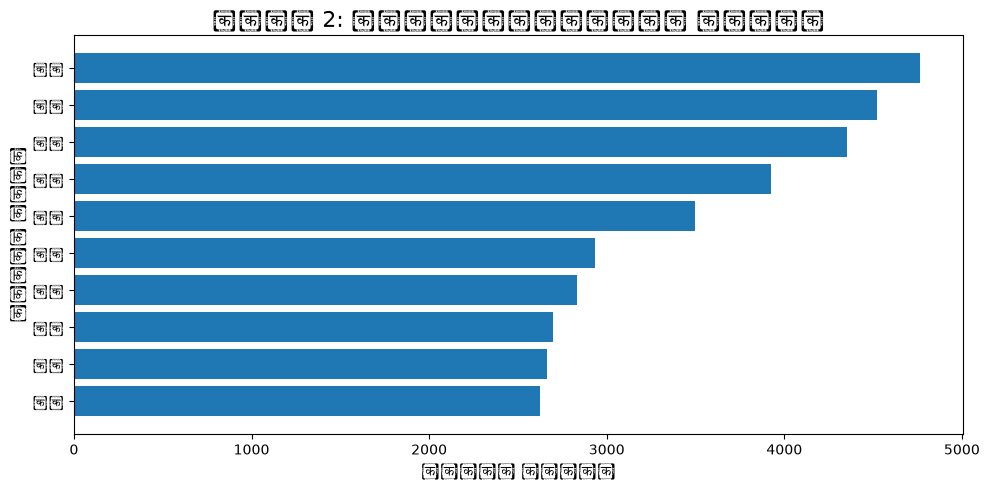

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2347 (\N{DEVANAGARI LETTER PHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2347 (\N{DEVANAGARI LETTER PHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2311 (\N{DEVANAGARI LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


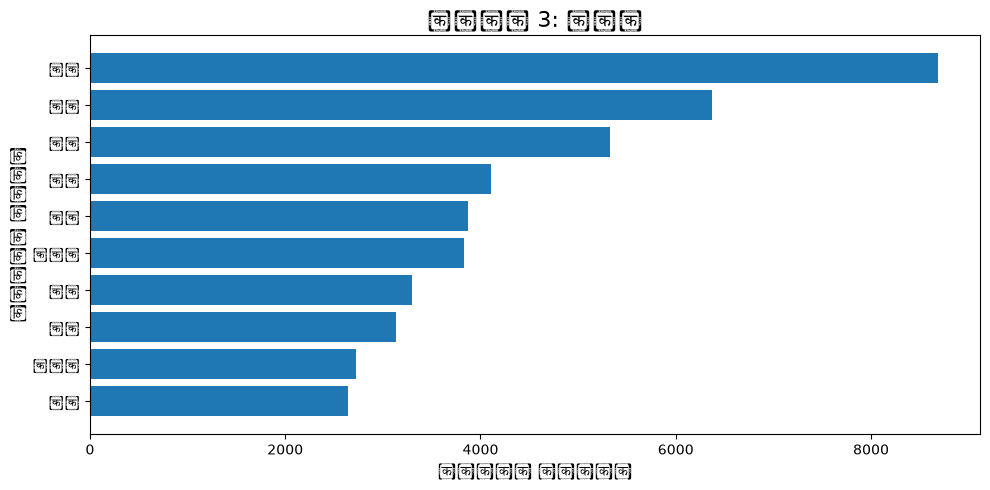

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2310 (\N{DEVANAGARI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


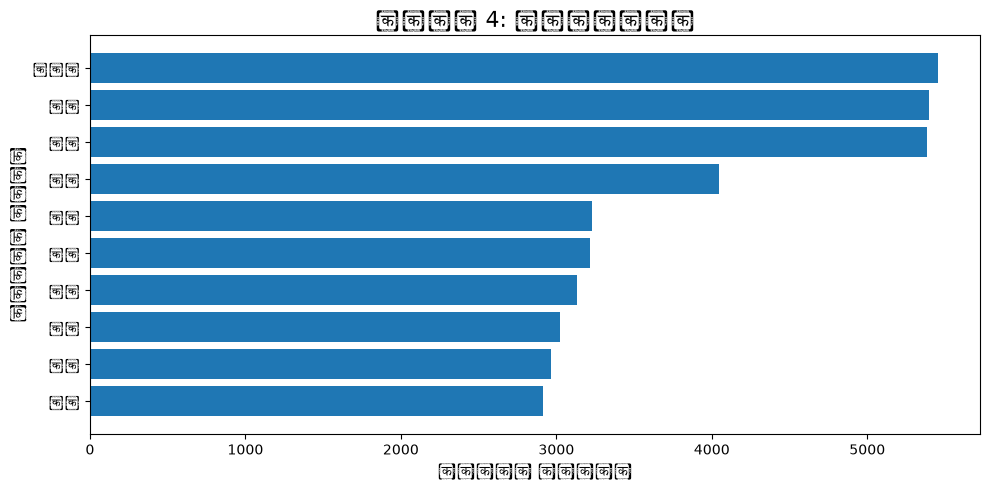

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2312 (\N{DEVANAGARI LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2324 (\N{DEVANAGARI LETTER AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2341 (\N{DEVANAGARI LETTER THA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2312 (\N{DEVANAGARI LETTER II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


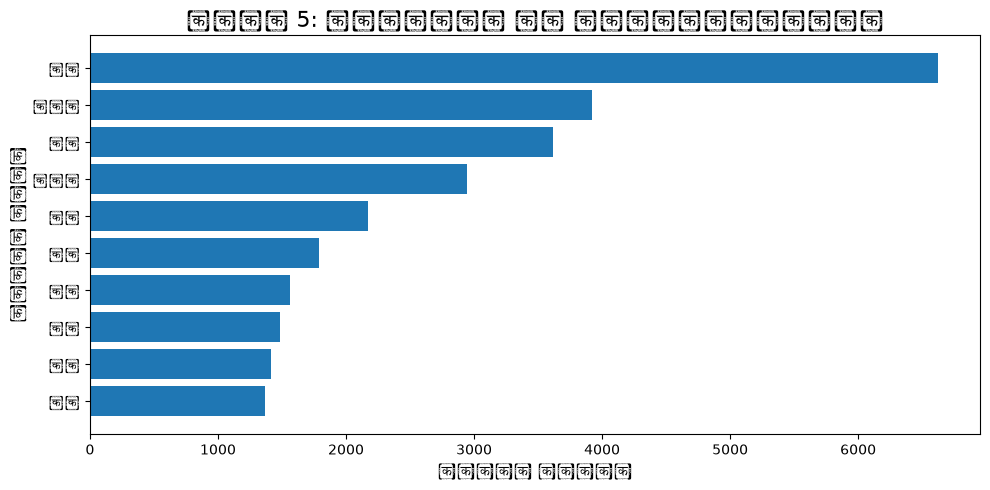

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


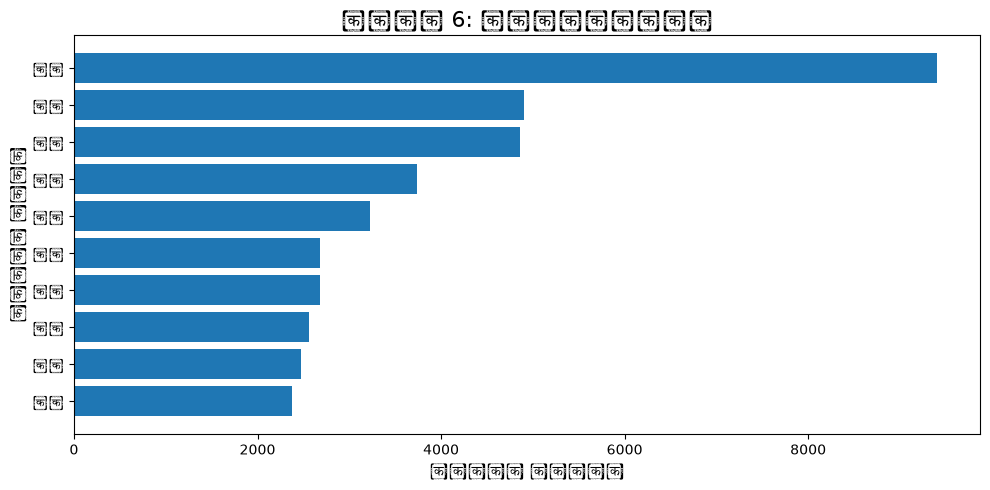

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2334 (\N{DEVANAGARI LETTER NYA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


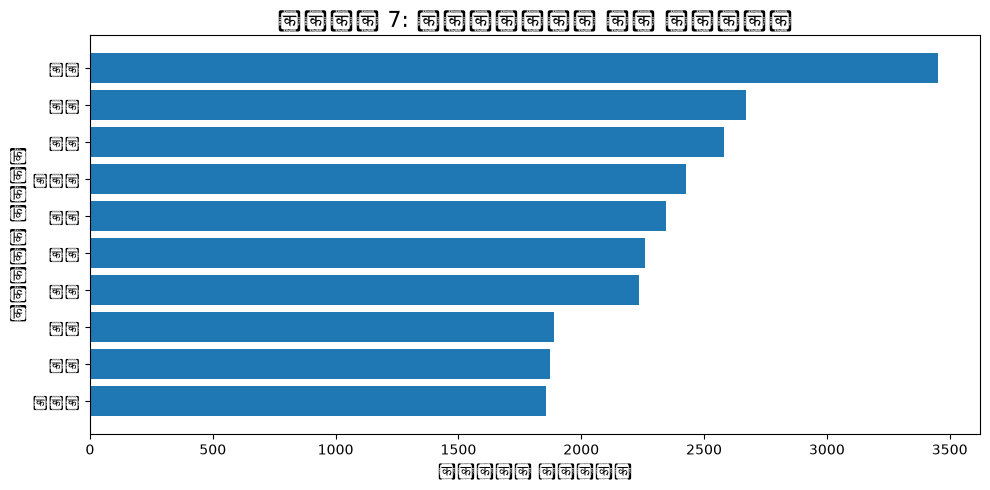

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3926756535.py:36: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


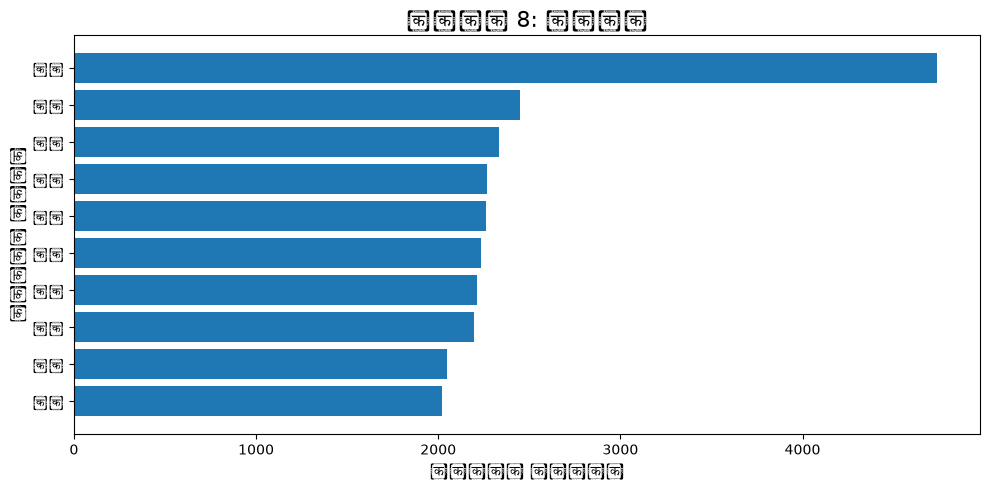

In [20]:
feature_names = vectorizer.get_feature_names_out()

for topic_num, words in topic_words.items():

    values = []

    for word in words:
        word_index = vectorizer.vocabulary_.get(word)

        values.append(
            lda_model.components_[topic_num - 1][word_index]
        )

    plt.figure(figsize=(10, 5))

    plt.barh(
        words[::-1],
        values[::-1]
    )

    plt.title(
        f"विषय {topic_num}: {topic_names[topic_num]}",
        fontsize=16
    )

    plt.xlabel(
        "महत्व स्कोर",
        fontsize=12
    )

    plt.ylabel(
        "मुख्य शब्द",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

In [21]:
topic_summary = []

for topic_num, words in topic_words.items():

    topic_summary.append({
        "विषय संख्या": topic_num,
        "विषय का नाम": topic_names[topic_num],
        "मुख्य शब्द": ", ".join(words),
        "समाचारों की संख्या": int(
            (df["topic"] == topic_num).sum()
        )
    })

topic_summary_df = pd.DataFrame(topic_summary)

display(topic_summary_df)

,विषय संख्या,विषय का नाम,मुख्य शब्द,समाचारों की संख्या
0,1,राजनीति,"रत, अम, ओल, कर, उन, मह, सम, मन, टर, डल",392
1,2,अंतरराष्ट्रीय मामले,"टर, तर, रत, कर, सर, पन, बढ, पर, अध, वर",785
2,3,खेल,"रत, बल, बन, कर, वर, ओवर, दब, उन, इनल, अफ",732
3,4,मनोरंजन,"सरक, रत, कर, मल, रक, अध, शन, उन, सम, आर",639
4,5,व्यापार और अर्थव्यवस्था,"इल, इसर, हम, हमल, टर, ईर, अम, कर, सम, बन",577
5,6,स्वास्थ्य,"रत, कर, पर, मह, उन, पत, हम, सम, बच, बत",516
6,7,विज्ञान और तकनीक,"कर, दव, सद, सरक, यक, रत, जन, रह, उम, रपत",463
7,8,समाज,"कर, रह, बन, कप, टर, उन, कह, हर, दर, लग",692


In [22]:
import re
import stopwordsiso as stopwords

hindi_stopwords = stopwords.stopwords("hi")

def preprocess_hindi(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove English letters, numbers and punctuation
    text = re.sub(r'[A-Za-z0-9]', ' ', text)
    text = re.sub(r'[^\u0900-\u097F\s]', ' ', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in hindi_stopwords
        and len(word) >= 3
    ]

    return ' '.join(words)

df["clean_text"] = df["text"].apply(preprocess_hindi)

print(df["clean_text"].head())

0    बांग्लादेश जमात इस्लामी मोदी बाइडन बातचीत दोनो...
1    भारत महिलाएं क्यों छिपाती मेनोपॉज़ मेरे पति चा...
2    वीडियो वडोदरा शहर करोड़ों रुपए बंगले पीने पानी...
3    अवनि लेखरा टोक्यो पेरिस गोल्ड साधा निशाना अवनि...
4    पैरालंपिक भाग्यश्री जाधव मेहनत लगन भाग्य बदलने...
Name: clean_text, dtype: str


In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    token_pattern=r'(?u)[\u0900-\u097F]{3,}',
    max_df=0.95,
    min_df=5,
    max_features=15000
)

X = vectorizer.fit_transform(df["clean_text"])

print("Document-Term Matrix:", X.shape)

Document-Term Matrix: (4796, 15000)


In [24]:
from sklearn.decomposition import LatentDirichletAllocation

n_topics = 8

lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

lda_model.fit(X)

print("LDA model trained successfully!")

LDA model trained successfully!


In [25]:
feature_names = vectorizer.get_feature_names_out()

topic_words = {}

for topic_idx, topic in enumerate(lda_model.components_):

    words = [
        feature_names[i]
        for i in topic.argsort()[:-11:-1]
    ]

    topic_words[topic_idx + 1] = words

    print(f"\nविषय {topic_idx + 1}")
    print(" | ".join(words))


विषय 1
लोगों | पुलिस | लोग | उन्होंने | बताया | बीबीसी | रही | पाकिस्तान | घटना | दिन

विषय 2
ओलंपिक | बांग्लादेश | भारत | भारतीय | पेरिस | महिला | उन्होंने | मेडल | हसीना | पदक

विषय 3
लोगों | काम | जाता | साल | कहती | रही | बात | अगर | उन्होंने | बीबीसी

विषय 4
चुनाव | पार्टी | बीजेपी | कांग्रेस | मोदी | सरकार | गांधी | लोकसभा | नेता | बार

विषय 5
फ़िल्म | उन्होंने | मैं | साल | बात | काम | मुझे | रही | नाम | बीबीसी

विषय 6
भारत | चीन | रूस | देशों | साल | अमेरिका | देश | यूक्रेन | बीच | रही

विषय 7
उन्होंने | सरकार | कोर्ट | राष्ट्रपति | इसराइल | भारत | मामले | लोगों | देश | बयान

विषय 8
टीम | मैच | क्रिकेट | भारत | विकेट | पाकिस्तान | उन्होंने | ओवर | भारतीय | वर्ल्ड


In [26]:
topic_names = {
    1: "अपराध, पुलिस और घटनाएँ",
    2: "ओलंपिक और अंतरराष्ट्रीय खेल",
    3: "समाज और जीवन",
    4: "भारतीय राजनीति",
    5: "फ़िल्म और मनोरंजन",
    6: "अंतरराष्ट्रीय मामले",
    7: "राजनीति और वैश्विक मामले",
    8: "क्रिकेट"
}

print("Hindi topic names assigned successfully!")

Hindi topic names assigned successfully!


In [27]:
topic_distribution = lda_model.transform(X)

df["topic"] = topic_distribution.argmax(axis=1) + 1

df["topic_name"] = df["topic"].map(topic_names)

print(df[["Headline", "Category", "topic", "topic_name"]].head(20))

                                             Headline Category  topic  \
0   बांग्लादेश जमात-ए-इस्लामी और मोदी-बाइडन की बात...     भारत      7   
1         भारत में महिलाएं क्यों छिपाती हैं मेनोपॉज़?     भारत      3   
2   वीडियो, 'वडोदरा शहर में करोड़ों रुपए के बंगले ...     भारत      1   
3   अवनि लेखरा: टोक्यो के बाद पेरिस में भी गोल्ड प...     भारत      2   
4   पैरालंपिक में भाग्यश्री जाधव: मेहनत और लगन से ...     भारत      3   
5   चंपाई सोरेन झारखंड में क्या बीजेपी को सत्ता तक...     भारत      4   
6   पुतिन को मंगोलिया में किया जाए गिरफ्तार, अंतरर...     भारत      7   
7   जय शाह: 35 साल की उम्र में क्रिकेट की दुनिया क...     भारत      8   
8   वेस्ट बैंक में इसराइल की कार्रवाई दूसरे दिन भी...     भारत      7   
9   एक दलित अधिकारी रेलवे में सबसे ऊंचे पद पर होंग...     भारत      4   
10  वीडियो, मनु भाकर ने सुनाई पिस्टल खराब होने के ...     भारत      2   
11  क्या हैं भविष्य की पांच नौकरियां और उनके लिए ज...     भारत      3   
12  बांग्लादेश में बाढ़ पर भारत को लेकर ग़ुस्सा, व.

In [28]:
topic_counts = (
    df["topic_name"]
    .value_counts()
    .reindex(topic_names.values())
)

print(topic_counts)

topic_name
अपराध, पुलिस और घटनाएँ         536
ओलंपिक और अंतरराष्ट्रीय खेल    310
समाज और जीवन                   472
भारतीय राजनीति                 398
फ़िल्म और मनोरंजन              863
अंतरराष्ट्रीय मामले            771
राजनीति और वैश्विक मामले       688
क्रिकेट                        758
Name: count, dtype: int64


C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\3101832421.py:43: UserWarning: Glyph 2

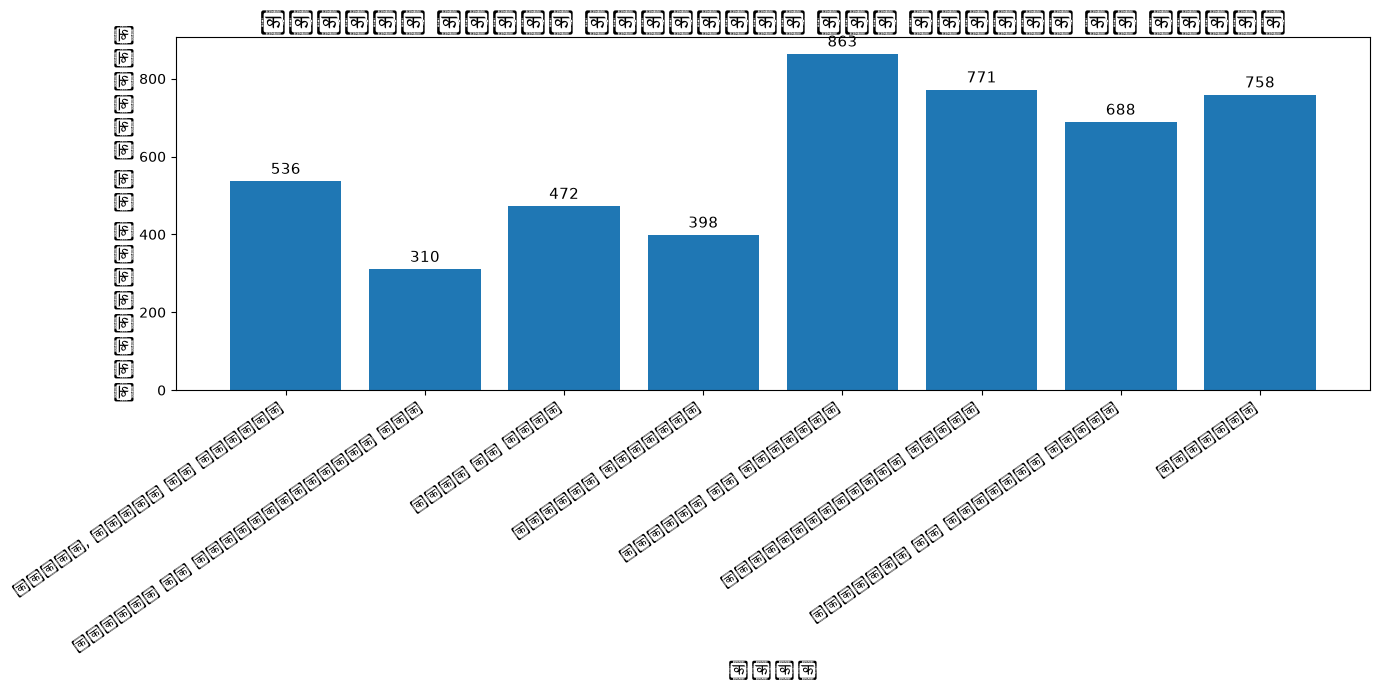

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

bars = plt.bar(
    topic_counts.index,
    topic_counts.values
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का वितरण",
    fontsize=18
)

plt.xlabel(
    "विषय",
    fontsize=14
)

plt.ylabel(
    "समाचारों की संख्या",
    fontsize=14
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=11
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2

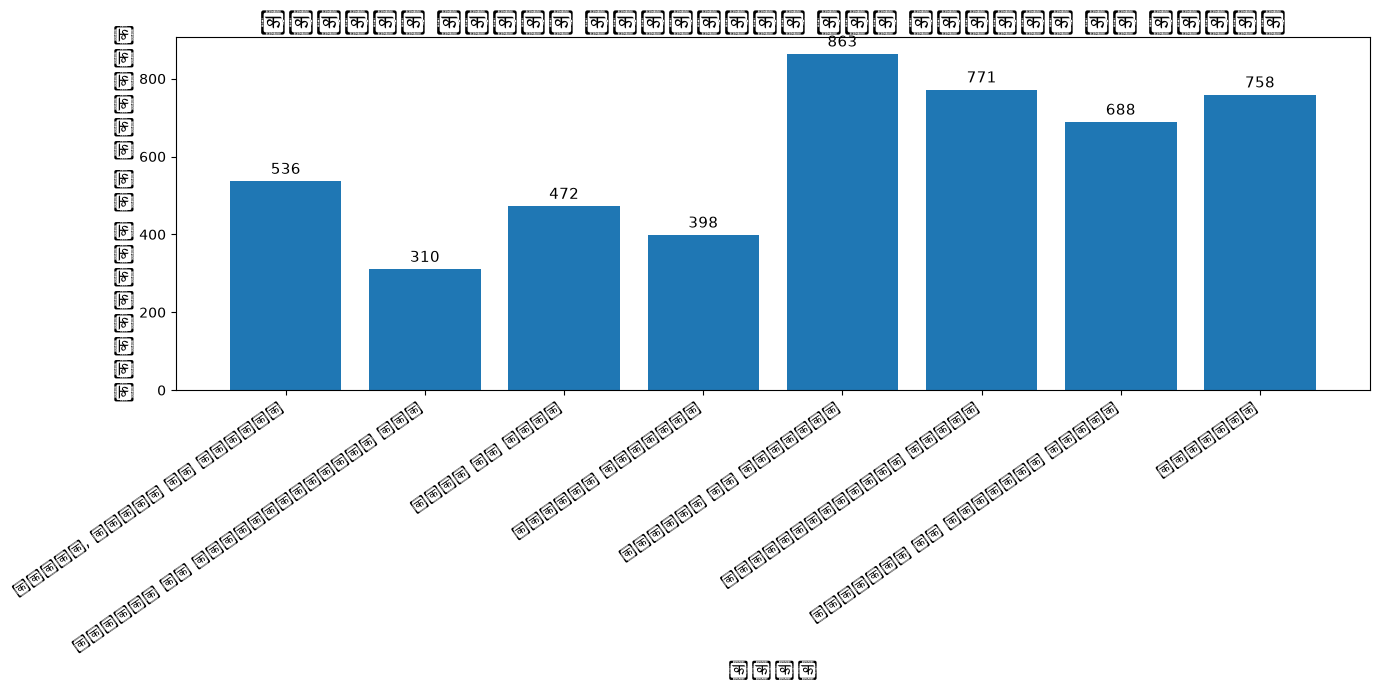

In [30]:
import matplotlib.pyplot as plt

# Topic counts in the desired order
topic_counts = (
    df["topic_name"]
    .value_counts()
    .reindex(topic_names.values())
)

plt.figure(figsize=(14, 7))

bars = plt.bar(
    topic_counts.index,
    topic_counts.values
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का वितरण",
    fontsize=18
)

plt.xlabel(
    "विषय",
    fontsize=14
)

plt.ylabel(
    "समाचारों की संख्या",
    fontsize=14
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=11
)

# Display article count above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [31]:
topic_counts = (
    df["topic_name"]
    .value_counts()
    .reindex(topic_names.values())
)

C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2346 (\N{DEVANAGARI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2343 (\N{DEVANAGARI LETTER DHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2354 (\N{DEVANAGARI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1369722912.py:51: UserWarning: Glyph 2

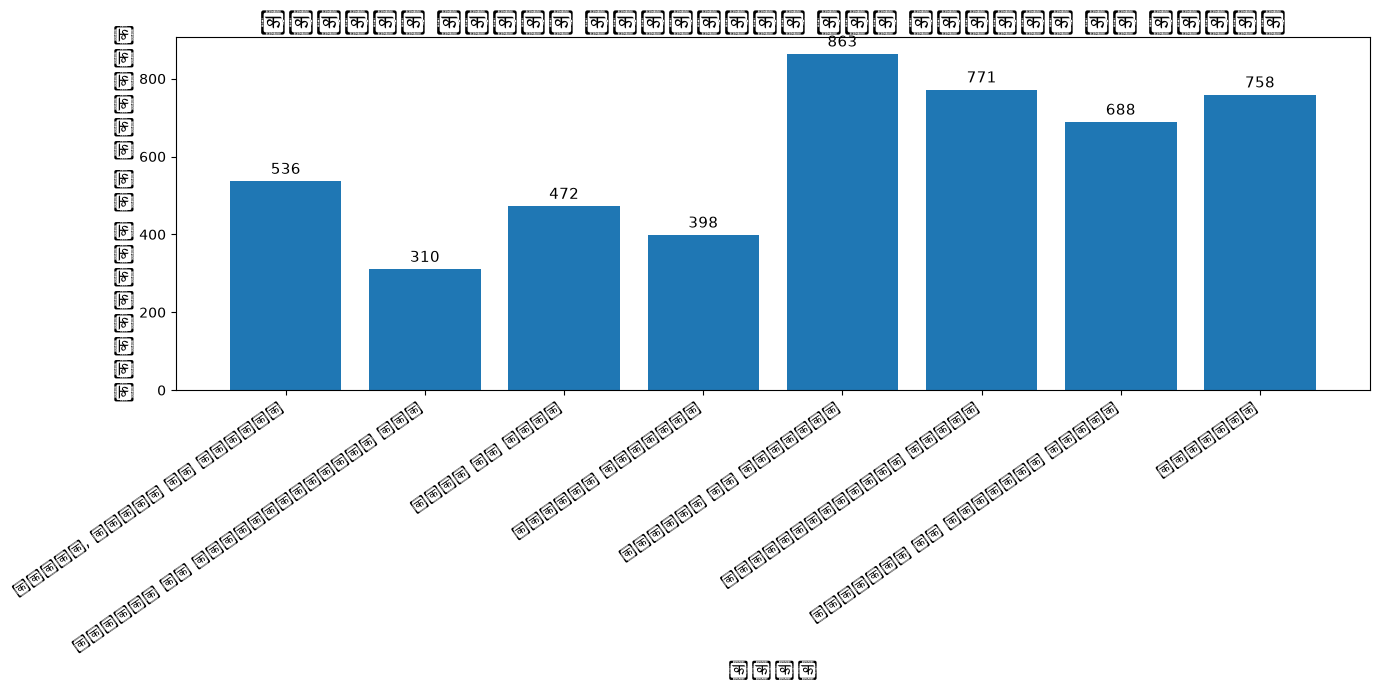

In [32]:
import matplotlib.pyplot as plt

# Topic counts in the desired order
topic_counts = (
    df["topic_name"]
    .value_counts()
    .reindex(topic_names.values())
)

plt.figure(figsize=(14, 7))

bars = plt.bar(
    topic_counts.index,
    topic_counts.values
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का वितरण",
    fontsize=18
)

plt.xlabel(
    "विषय",
    fontsize=14
)

plt.ylabel(
    "समाचारों की संख्या",
    fontsize=14
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=11
)

# Display article count above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [33]:
import matplotlib.font_manager as fm

fonts = fm.findSystemFonts()

hindi_fonts = [
    f for f in fonts
    if any(name in f.lower() for name in [
        "nirmala", "mangal", "kokila", "aparajita"
    ])
]

print(hindi_fonts)

['C:\\Windows\\Fonts\\kokila.ttf', 'C:\\Windows\\Fonts\\kokilabi.ttf', 'C:\\Windows\\Fonts\\mangalb.ttf', 'C:\\Windows\\Fonts\\kokilai.ttf', 'C:\\Windows\\Fonts\\Nirmala.ttc', 'C:\\Windows\\Fonts\\mangal.ttf', 'C:\\Windows\\Fonts\\kokilab.ttf']


In [34]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Find a Devanagari-compatible Windows font
font_path = None

preferred_fonts = ["Nirmala.ttf", "mangal.ttf", "kokila.ttf", "aparaj.ttf"]

for path in fm.findSystemFonts():
    filename = path.lower()

    if any(font.lower() in filename for font in preferred_fonts):
        font_path = path
        break

print("Hindi font:", font_path)

Hindi font: C:\Windows\Fonts\kokila.ttf


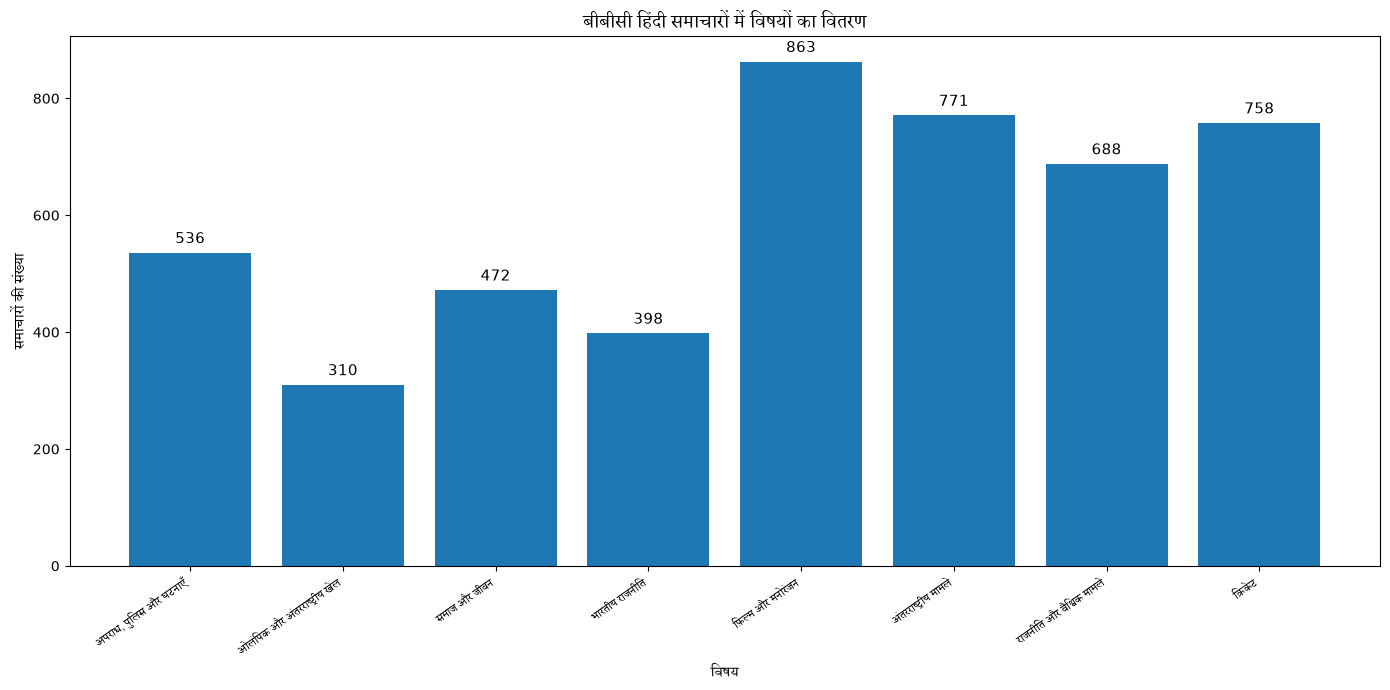

In [35]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname=font_path)

topic_counts = (
    df["topic_name"]
    .value_counts()
    .reindex(topic_names.values())
)

plt.figure(figsize=(14, 7))

bars = plt.bar(
    range(len(topic_counts)),
    topic_counts.values
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का वितरण",
    fontproperties=font,
    fontsize=18
)

plt.xlabel(
    "विषय",
    fontproperties=font,
    fontsize=14
)

plt.ylabel(
    "समाचारों की संख्या",
    fontproperties=font,
    fontsize=14
)

plt.xticks(
    range(len(topic_counts)),
    topic_counts.index,
    rotation=35,
    ha="right",
    fontproperties=font,
    fontsize=11
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        str(int(height)),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

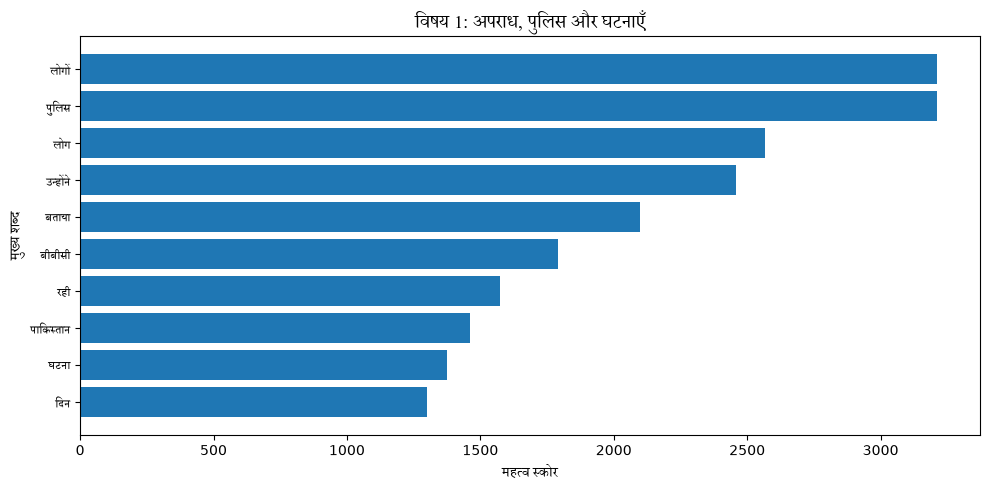

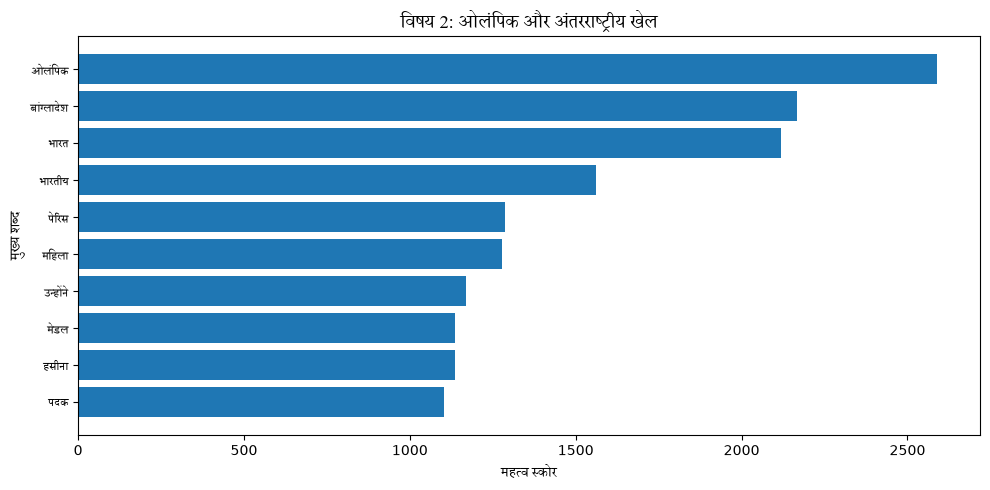

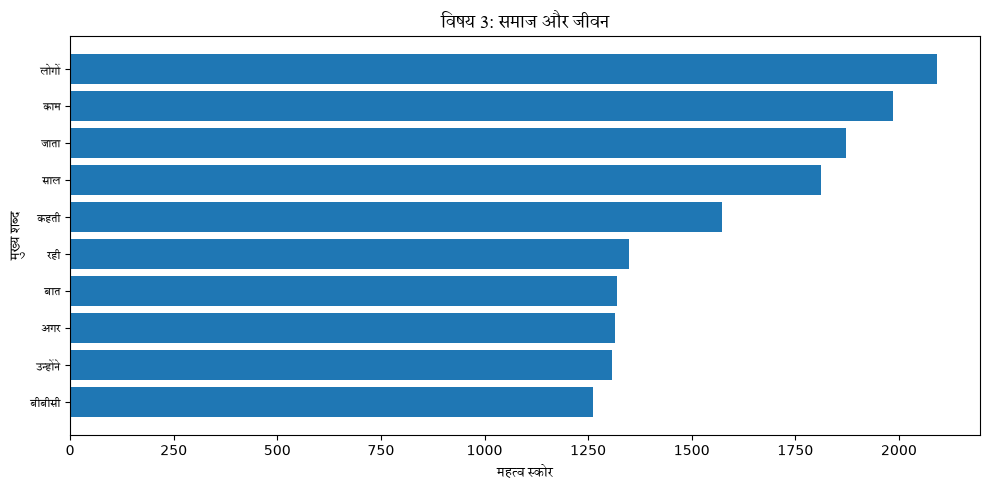

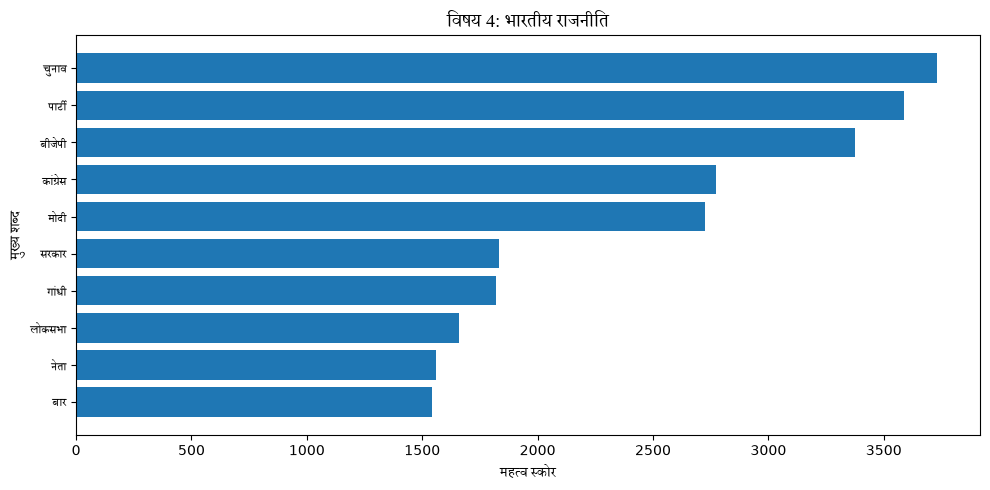

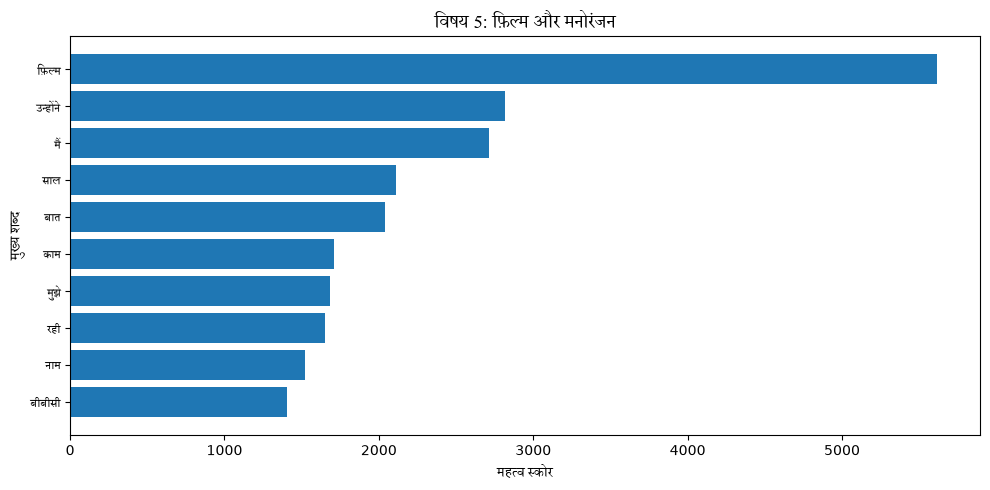

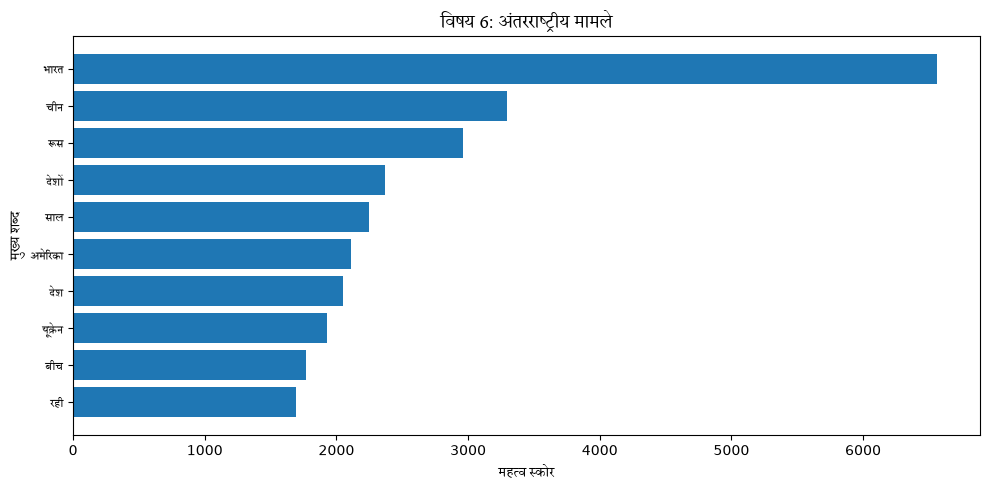

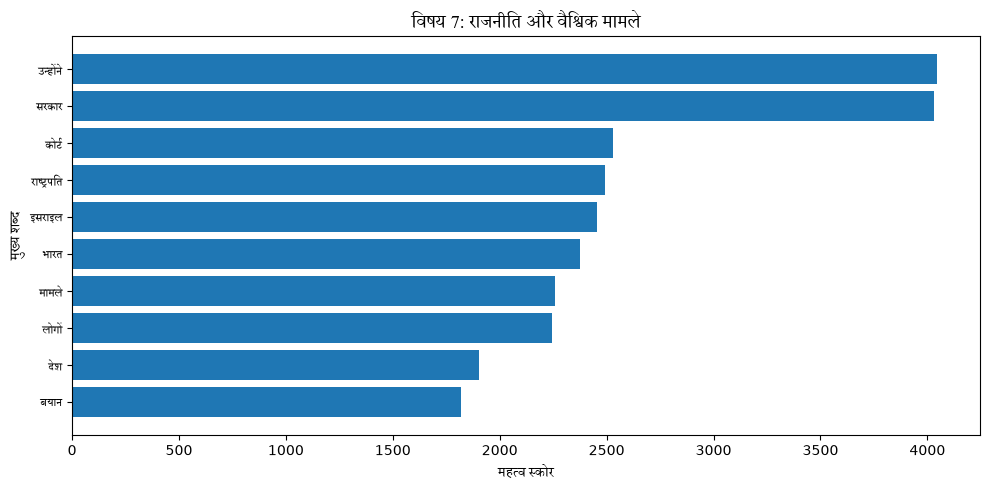

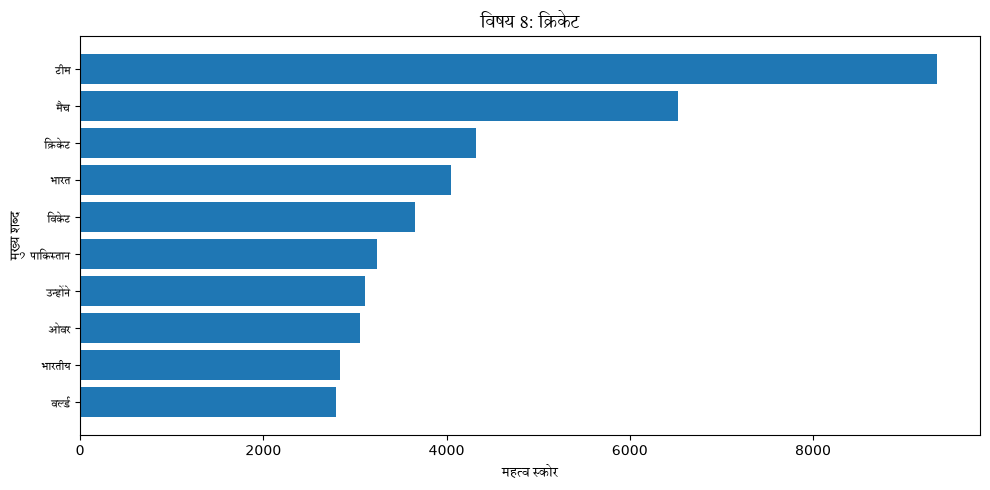

In [36]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname=font_path)

feature_names = vectorizer.get_feature_names_out()

for topic_num in range(1, 9):

    topic = lda_model.components_[topic_num - 1]

    top_indices = topic.argsort()[-10:][::-1]

    words = feature_names[top_indices]
    scores = topic[top_indices]

    plt.figure(figsize=(10, 5))

    plt.barh(
        range(len(words)),
        scores[::-1]
    )

    plt.yticks(
        range(len(words)),
        words[::-1],
        fontproperties=font,
        fontsize=11
    )

    plt.title(
        f"विषय {topic_num}: {topic_names[topic_num]}",
        fontproperties=font,
        fontsize=17
    )

    plt.xlabel(
        "महत्व स्कोर",
        fontproperties=font,
        fontsize=13
    )

    plt.ylabel(
        "मुख्य शब्द",
        fontproperties=font,
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

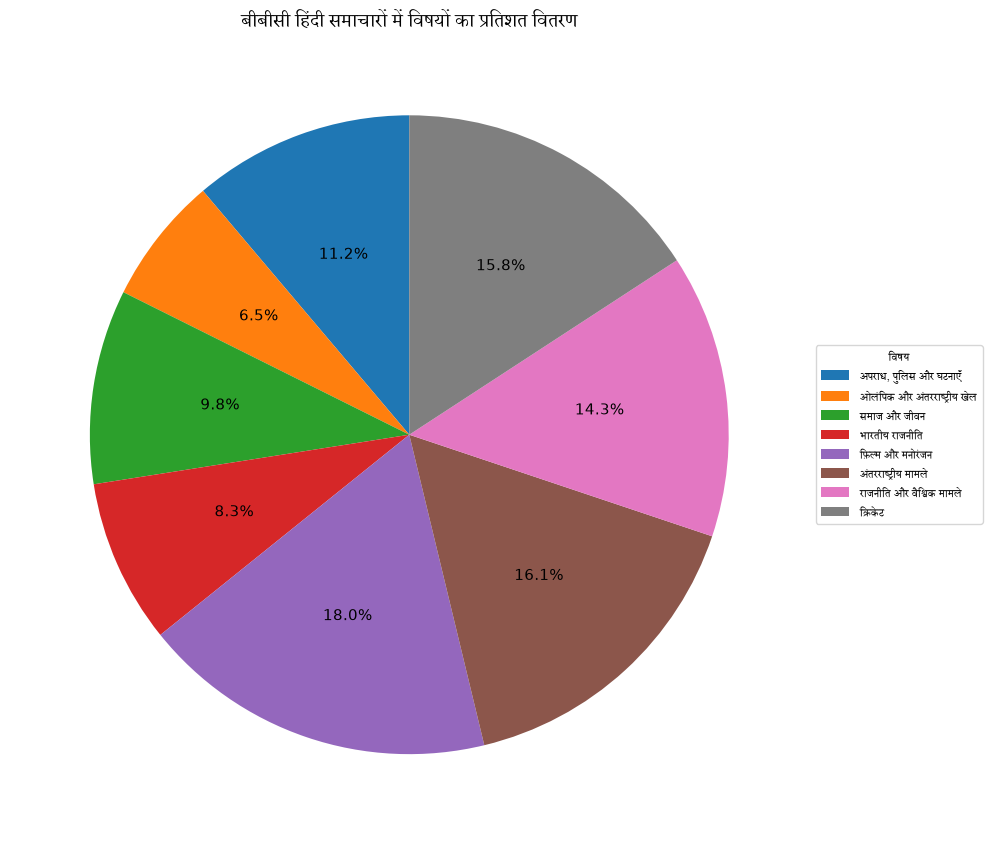

In [37]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname=font_path)

plt.figure(figsize=(10, 10))

plt.pie(
    topic_counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11}
)

# Hindi legend instead of pie labels
plt.legend(
    topic_counts.index,
    title="विषय",
    prop=font,
    title_fontproperties=font,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title(
    "बीबीसी हिंदी समाचारों में विषयों का प्रतिशत वितरण",
    fontproperties=font,
    fontsize=18
)

plt.tight_layout()
plt.show()

In [38]:
topic_summary = []

feature_names = vectorizer.get_feature_names_out()

for topic_num in range(1, 9):

    topic = lda_model.components_[topic_num - 1]

    top_indices = topic.argsort()[-10:][::-1]

    words = feature_names[top_indices]

    article_count = (df["topic"] == topic_num).sum()

    topic_summary.append({
        "विषय संख्या": topic_num,
        "विषय का नाम": topic_names[topic_num],
        "मुख्य शब्द": ", ".join(words),
        "समाचारों की संख्या": int(article_count)
    })

topic_summary_df = pd.DataFrame(topic_summary)

display(topic_summary_df)

,विषय संख्या,विषय का नाम,मुख्य शब्द,समाचारों की संख्या
0,1,"अपराध, पुलिस और घटनाएँ","लोगों, पुलिस, लोग, उन्होंने, बताया, बीबीसी, रह...",536
1,2,ओलंपिक और अंतरराष्ट्रीय खेल,"ओलंपिक, बांग्लादेश, भारत, भारतीय, पेरिस, महिला...",310
2,3,समाज और जीवन,"लोगों, काम, जाता, साल, कहती, रही, बात, अगर, उन...",472
3,4,भारतीय राजनीति,"चुनाव, पार्टी, बीजेपी, कांग्रेस, मोदी, सरकार, ...",398
4,5,फ़िल्म और मनोरंजन,"फ़िल्म, उन्होंने, मैं, साल, बात, काम, मुझे, रह...",863
5,6,अंतरराष्ट्रीय मामले,"भारत, चीन, रूस, देशों, साल, अमेरिका, देश, यूक्...",771
6,7,राजनीति और वैश्विक मामले,"उन्होंने, सरकार, कोर्ट, राष्ट्रपति, इसराइल, भा...",688
7,8,क्रिकेट,"टीम, मैच, क्रिकेट, भारत, विकेट, पाकिस्तान, उन्...",758


In [39]:
for topic_num in range(1, 9):

    print("\n" + "=" * 80)

    print(
        f"विषय {topic_num}: {topic_names[topic_num]}"
    )

    print("=" * 80)

    articles = (
        df[df["topic"] == topic_num]["Headline"]
        .head(5)
    )

    for headline in articles:
        print("•", headline)


विषय 1: अपराध, पुलिस और घटनाएँ
• वीडियो, 'वडोदरा शहर में करोड़ों रुपए के बंगले हैं, लेकिन पीने का पानी मयस्सर नहीं है', अवधि 4,37
• इस्लामाबाद की लाल मस्जिद में पाकिस्तानी सेना के ऑपरेशन की कहानी
• वीडियो, कोलकाता में विरोध प्रदर्शन, पूरे दिन क्या-क्या हुआ?, अवधि 4,17
• बिहार: खेत में बने वायरल पुलों की असली कहानी क्या है?
• वीडियो, बेमिसाल काम कर रही हैं ये ट्रांसजेंडर , अवधि 3,31

विषय 2: ओलंपिक और अंतरराष्ट्रीय खेल
• अवनि लेखरा: टोक्यो के बाद पेरिस में भी गोल्ड पर साधा निशाना
• वीडियो, मनु भाकर ने सुनाई पिस्टल खराब होने के बाद से पदक जीतने तक कहानी, अवधि 6,38
• शीतल बिना हाथ के कैसे बनीं तीरंदाज, निशाना अब गोल्ड के लिए
• वीडियो, बांग्लादेश ने अगर शेख़ हसीना को वापस भेजने के लिए कहा तो भारत क्या करेगा?, अवधि 4,38
• पेरिस पैरालंपिक 2024: भारत की तरफ़ से कौन हैं मेडल के प्रबल दावेदार

विषय 3: समाज और जीवन
• भारत में महिलाएं क्यों छिपाती हैं मेनोपॉज़?
• पैरालंपिक में भाग्यश्री जाधव: मेहनत और लगन से भाग्य बदलने की कहानी
• क्या हैं भविष्य की पांच नौकरियां और उनके लिए ज़रूरी हुनर
• ड्यूटी

In [40]:
topic_category = pd.crosstab(
    df["topic_name"],
    df["Category"]
)

display(topic_category)

Category,खेल,भारत,मनोरंजन,विज्ञान,विदेश,सोशल
topic_name,,,,,,
अंतरराष्ट्रीय मामले,22,89,30,318,294,18
"अपराध, पुलिस और घटनाएँ",20,191,36,102,126,61
ओलंपिक और अंतरराष्ट्रीय खेल,193,58,7,8,39,5
क्रिकेट,577,58,19,28,45,31
फ़िल्म और मनोरंजन,40,66,533,83,35,106
भारतीय राजनीति,13,233,20,58,43,31
राजनीति और वैश्विक मामले,39,204,47,76,290,32
समाज और जीवन,19,54,12,286,82,19


C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2325 (\N{DEVANAGARI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Punam kumari\AppData\Local\Temp\ipykernel_50088\1258450283.py:46: UserWarning: Glyph 2

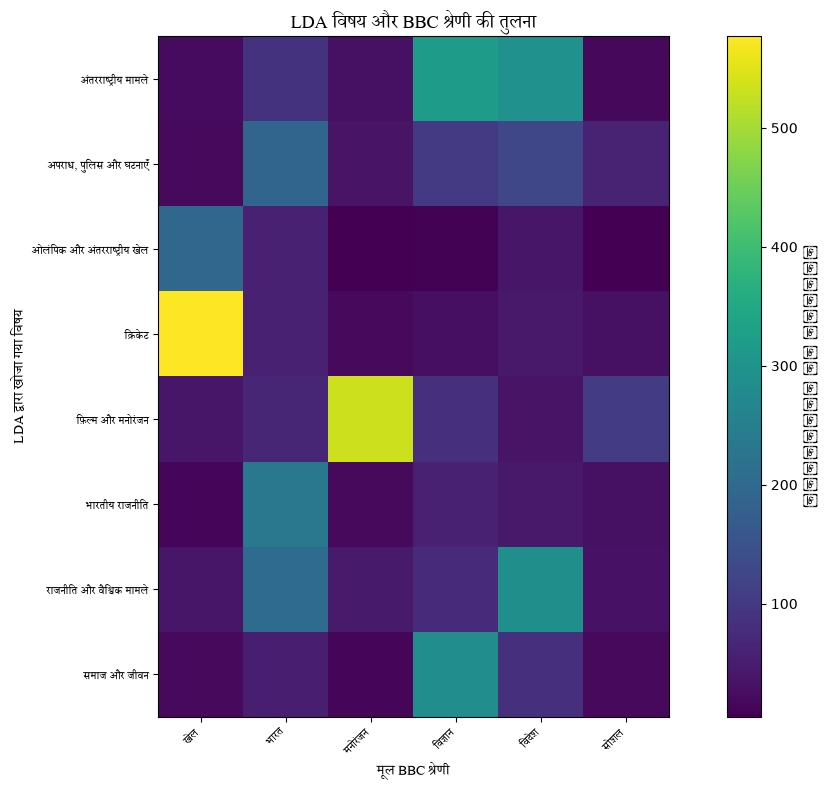

In [41]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font = FontProperties(fname=font_path)

plt.figure(figsize=(12, 8))

plt.imshow(topic_category.values)

plt.colorbar(
    label="समाचारों की संख्या"
)

plt.xticks(
    range(len(topic_category.columns)),
    topic_category.columns,
    rotation=45,
    ha="right",
    fontproperties=font
)

plt.yticks(
    range(len(topic_category.index)),
    topic_category.index,
    fontproperties=font
)

plt.xlabel(
    "मूल BBC श्रेणी",
    fontproperties=font,
    fontsize=13
)

plt.ylabel(
    "LDA द्वारा खोजा गया विषय",
    fontproperties=font,
    fontsize=13
)

plt.title(
    "LDA विषय और BBC श्रेणी की तुलना",
    fontproperties=font,
    fontsize=17
)

plt.tight_layout()
plt.show()

In [42]:
output_file = "bbc_hindi_topic_modeling_results.csv"

df.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print("Results saved successfully!")
print(output_file)

Results saved successfully!
bbc_hindi_topic_modeling_results.csv
